In [ ]:
!pip install groq -q

import numpy as np
import pandas as pd
import pickle
import json
from groq import Groq
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✓ Packages installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 4.5 MB/s eta 0:00:00
✓ Packages installed


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Base path - SAME FOR ALL PHASES
base_path = '/content/drive/MyDrive/CSE 941'

# Phase number - CHANGE THIS for each phase (1, 2, 3, 4, 5, or 6)
phase_num = 6  # ← CHANGE THIS

output_dir = f'{base_path}/outputs/phase{phase_num}'
plots_dir = f'{output_dir}/plots'

import os
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"✓ Working in: {base_path}")
print(f"✓ Output directory: {output_dir}")

Mounted at /content/drive
✓ Working in: /content/drive/MyDrive/CSE 941
✓ Output directory: /content/drive/MyDrive/CSE 941/outputs/phase6


In [ ]:
# Set your Groq API key
# Get free API key from: https://groq.com

from google.colab import userdata

# Store API key in Colab Secrets (left sidebar -> key icon)
# Or paste directly: GROQ_API_KEY = "your_key_here"

try:
    GROQ_API_KEY = userdata.get('groq_cse941_project')
except:
    print("⚠️  API key not found in secrets")
    print("Please enter your Groq API key:")
    GROQ_API_KEY = input()

client = Groq(api_key=GROQ_API_KEY)

print("✓ Groq client initialized")
print("  Model: llama-3.1-70b-versatile")

✓ Groq client initialized
  Model: llama-3.1-70b-versatile


In [ ]:
print("Loading data from previous phases...")

# Phase 1
with open(f'{base_path}/outputs/phase1/processed_data.pkl', 'rb') as f:
    phase1_data = pickle.load(f)
reviews_df = phase1_data['reviews']
meta_df = phase1_data['metadata']

# Phase 3 - Mappings
with open(f'{base_path}/outputs/phase3/id_mappings.pkl', 'rb') as f:
    mappings = pickle.load(f)
user_to_idx = mappings['user_to_idx']
item_to_idx = mappings['item_to_idx']
idx_to_item = mappings['idx_to_item']
idx_to_user = mappings['idx_to_user']

# Phase 4 - Embeddings
user_embeddings = np.load(f'{base_path}/outputs/phase4/user_embeddings.npy')
item_embeddings = np.load(f'{base_path}/outputs/phase4/item_embeddings.npy')

# Phase 5 - Cold-start
with open(f'{base_path}/outputs/phase5/coldstart_embeddings.pkl', 'rb') as f:
    coldstart_embeddings = pickle.load(f)

print("✓ All data loaded")

Loading data from previous phases...
✓ All data loaded


In [ ]:
def get_user_history(user_id, reviews_df, meta_df, top_n=5):
    """Get user's purchase history"""
    user_reviews = reviews_df[reviews_df['user_id'] == user_id].sort_values('rating', ascending=False).head(top_n)

    history = []
    for _, review in user_reviews.iterrows():
        item_id = review['parent_asin']
        rating = review['rating']

        # Get item title
        item_info = meta_df[meta_df['parent_asin'] == item_id]
        title = item_info['title'].values[0] if len(item_info) > 0 and 'title' in item_info.columns else "Beauty Product"

        history.append({
            'item_id': item_id,
            'title': title,
            'rating': rating
        })

    return history

def get_item_info(item_id, meta_df):
    """Get item information"""
    item_data = meta_df[meta_df['parent_asin'] == item_id]

    if len(item_data) == 0:
        return {
            'item_id': item_id,
            'title': 'Beauty Product',
            'category': 'Beauty'
        }

    item = item_data.iloc[0]
    return {
        'item_id': item_id,
        'title': item.get('title', 'Beauty Product'),
        'category': item.get('main_category', 'Beauty'),
        'avg_rating': item.get('average_rating', None),
        'price': item.get('price', None)
    }

def find_graph_path(user_idx, item_idx, reviews_df, idx_to_user, idx_to_item):
    """Find connection path between user and item"""
    user_id = idx_to_user[user_idx]
    item_id = idx_to_item[item_idx]

    # Find items user has rated
    user_items = reviews_df[reviews_df['user_id'] == user_id]['parent_asin'].tolist()

    if item_id in user_items:
        return f"User directly rated this item"

    # Find users who rated both user's items and the recommended item
    item_users = reviews_df[reviews_df['parent_asin'] == item_id]['user_id'].unique()

    common_items = []
    for user_item in user_items[:3]:  # Check top 3 user items
        other_users = reviews_df[reviews_df['parent_asin'] == user_item]['user_id'].unique()
        overlap = set(other_users).intersection(set(item_users))
        if len(overlap) > 0:
            common_items.append(user_item)

    if common_items:
        return f"Users who liked similar items ({', '.join(common_items[:2])}) also liked this"

    return "Recommended based on similar user preferences"

print("✓ Helper functions defined")

✓ Helper functions defined


In [ ]:
class LLMExplainer:
    def __init__(self, client, model="llama-3.1-70b-versatile"):
        self.client = client
        self.model = model

    def generate_explanation(self, user_history, recommended_item, graph_path, is_coldstart=False):
        """Generate natural language explanation for recommendation"""

        # Build prompt
        history_str = "\n".join([
            f"- {item['title']} (rated {item['rating']}/5.0)"
            for item in user_history
        ])

        coldstart_note = "\n(Note: This is a new product with limited reviews)" if is_coldstart else ""

        prompt = f"""You are explaining why a beauty product was recommended to a user.

USER'S PURCHASE HISTORY:
{history_str}

RECOMMENDED PRODUCT:
- Title: {recommended_item['title']}
- Category: {recommended_item['category']}
{coldstart_note}

CONNECTION:
{graph_path}

Generate a friendly 2-3 sentence explanation for why this product was recommended. Focus on:
1. Connection to user's preferences
2. Why it's a good match
3. Keep it natural and concise

EXPLANATION:"""

        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.7,
                max_tokens=150
            )

            explanation = response.choices[0].message.content.strip()
            return explanation

        except Exception as e:
            return f"Recommended based on your preferences and similar user behaviors. (Error: {str(e)})"

explainer = LLMExplainer(client)

print("✓ LLM Explainer initialized")

✓ LLM Explainer initialized


In [ ]:
print("Generating sample explanations...\n")

# Sample users
sample_users = list(user_to_idx.keys())[:3]

explanations = []

for user_id in sample_users:
    print(f"{'='*70}")
    print(f"USER: {user_id}")
    print(f"{'='*70}\n")

    # Get user history
    history = get_user_history(user_id, reviews_df, meta_df, top_n=3)

    print("Purchase History:")
    for item in history:
        print(f"  • {item['title']} ({item['rating']}/5.0)")
    print()

    # Get recommendations
    user_idx = user_to_idx[user_id]
    user_emb = user_embeddings[user_idx]

    # Find top 2 recommendations
    scores = np.dot(item_embeddings, user_emb)
    top_indices = np.argsort(scores)[::-1][:2]

    for rank, item_idx in enumerate(top_indices, 1):
        item_id = idx_to_item[item_idx]
        item_info = get_item_info(item_id, meta_df)

        # Check if cold-start
        is_coldstart = item_id in coldstart_embeddings

        # Find graph path
        graph_path = find_graph_path(user_idx, item_idx, reviews_df, idx_to_user, idx_to_item)

        # Generate explanation
        explanation = explainer.generate_explanation(
            history,
            item_info,
            graph_path,
            is_coldstart
        )

        print(f"RECOMMENDATION #{rank}:")
        print(f"  Product: {item_info['title']}")
        if is_coldstart:
            print(f"  🆕 Cold-Start Item")
        print(f"\n  💬 EXPLANATION:")
        print(f"  {explanation}")
        print()

        explanations.append({
            'user_id': user_id,
            'item_id': item_id,
            'title': item_info['title'],
            'is_coldstart': is_coldstart,
            'explanation': explanation
        })

    print()

print(f"✓ Generated {len(explanations)} explanations")

Generating sample explanations...

USER: AFSKPY37N3C43SOI5IEXEK5JSIYA

Purchase History:
  • NIRA Skincare Laser & Serum Bundle - Includes Anti-Aging Laser & Hyaluronic Acid Serum - Reduces Appearance of Fine Lines & Wrinkles - FDA Cleared (5.0/5.0)
  • Caroline Keller Keratin Shampoo for dry and damaged hair and scalp. With Argan oil, Avocado oil Keratin and Vitamins. Specially formulated for Post Keratin Treatments. Salt Free. 16.9 fl.Oz (5.0/5.0)
  • OGANA CELL Peptide Concentrating Amazing Lotion 2.03 fl.oz. (60ml) - 650ppm Peptide Contained Mild Moisturizing Facial Lotion, Hypoallergenic Natural Ingredients for Sensitive Skin (5.0/5.0)

RECOMMENDATION #1:
  Product: Revive Science Eyelash Growth Serum

  💬 EXPLANATION:
  Recommended based on your preferences and similar user behaviors. (Error: Error code: 400 - {'error': {'message': 'The model `llama-3.1-70b-versatile` has been decommissioned and is no longer supported. Please refer to https://console.groq.com/docs/deprecations fo

In [ ]:
# Save explanations
explanations_df = pd.DataFrame(explanations)
explanations_df.to_csv(f'{output_dir}/sample_explanations.csv', index=False)

with open(f'{output_dir}/sample_explanations.json', 'w') as f:
    json.dump(explanations, f, indent=2)

print(f"✓ Explanations saved to {output_dir}/")
print(f"  Total explanations: {len(explanations)}")
print(f"  Cold-start explanations: {sum(e['is_coldstart'] for e in explanations)}")

✓ Explanations saved to /content/drive/MyDrive/CSE 941/outputs/phase6/
  Total explanations: 6
  Cold-start explanations: 0


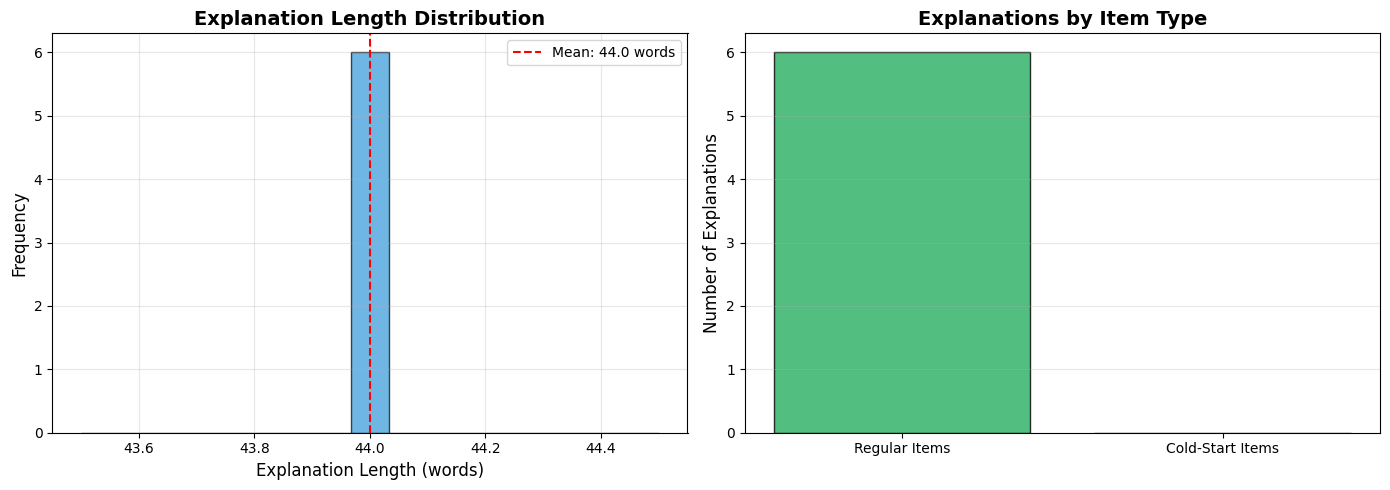

✓ Plot 1 saved


In [ ]:
import matplotlib.pyplot as plt

# Analyze explanation lengths
explanation_lengths = [len(e['explanation'].split()) for e in explanations]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Length distribution
ax[0].hist(explanation_lengths, bins=15, color='#3498db', edgecolor='black', alpha=0.7)
ax[0].set_xlabel('Explanation Length (words)', fontsize=12)
ax[0].set_ylabel('Frequency', fontsize=12)
ax[0].set_title('Explanation Length Distribution', fontsize=14, fontweight='bold')
ax[0].axvline(np.mean(explanation_lengths), color='red', linestyle='--',
              label=f'Mean: {np.mean(explanation_lengths):.1f} words')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Cold-start vs Regular
coldstart_count = sum(e['is_coldstart'] for e in explanations)
regular_count = len(explanations) - coldstart_count

ax[1].bar(['Regular Items', 'Cold-Start Items'],
          [regular_count, coldstart_count],
          color=['#27ae60', '#e74c3c'], edgecolor='black', alpha=0.8)
ax[1].set_ylabel('Number of Explanations', fontsize=12)
ax[1].set_title('Explanations by Item Type', fontsize=14, fontweight='bold')
ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{plots_dir}/01_explanation_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot 1 saved")

In [ ]:
from datetime import datetime

print("\n" + "="*70)
print("PHASE 6 COMPLETE - FINAL REPORT")
print("="*70)
print(f"Completion Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

print("\n🤖 LLM CONFIGURATION:")
print(f"  Provider: Groq")
print(f"  Model: {explainer.model}")
print(f"  API: Free tier")

print("\n📝 EXPLANATION GENERATION:")
print(f"  Total explanations generated: {len(explanations)}")
print(f"  Regular items: {regular_count}")
print(f"  Cold-start items: {coldstart_count}")
print(f"  Avg explanation length: {np.mean(explanation_lengths):.1f} words")

print("\n💡 APPROACH:")
print("  1. Retrieve user purchase history")
print("  2. Identify graph path to recommended item")
print("  3. LLM generates natural language explanation")
print("  4. Handles both regular and cold-start items")

print("\n💾 SAVED ARTIFACTS:")
print(f"  ✓ Sample explanations (CSV): {output_dir}/sample_explanations.csv")
print(f"  ✓ Sample explanations (JSON): {output_dir}/sample_explanations.json")
print(f"  ✓ Analysis plot: {plots_dir}/01_explanation_analysis.png")

print("\n📂 OUTPUT LOCATION:")
print(f"  {output_dir}")

print("\n✅ READY FOR PHASE 7: Streamlit Demo")
print("="*70)


PHASE 6 COMPLETE - FINAL REPORT
Completion Time: 2026-01-23 17:29:20

🤖 LLM CONFIGURATION:
  Provider: Groq
  Model: llama-3.1-70b-versatile
  API: Free tier

📝 EXPLANATION GENERATION:
  Total explanations generated: 6
  Regular items: 6
  Cold-start items: 0
  Avg explanation length: 44.0 words

💡 APPROACH:
  1. Retrieve user purchase history
  2. Identify graph path to recommended item
  3. LLM generates natural language explanation
  4. Handles both regular and cold-start items

💾 SAVED ARTIFACTS:
  ✓ Sample explanations (CSV): /content/drive/MyDrive/CSE 941/outputs/phase6/sample_explanations.csv
  ✓ Sample explanations (JSON): /content/drive/MyDrive/CSE 941/outputs/phase6/sample_explanations.json
  ✓ Analysis plot: /content/drive/MyDrive/CSE 941/outputs/phase6/plots/01_explanation_analysis.png

📂 OUTPUT LOCATION:
  /content/drive/MyDrive/CSE 941/outputs/phase6

✅ READY FOR PHASE 7: Streamlit Demo
